# Data Collection

In [1]:
# Load the datasets

import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
os.makedirs("outputs", exist_ok=True)


sentiment = pd.read_csv("../data/fear_greed_index_sentiment.csv")
trader = pd.read_csv("../data/trader_historical_data.csv")


In [2]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [3]:
trader.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


# Data Understanding (EDA)

In [4]:
sentiment.shape

(2644, 4)

In [5]:
trader.shape

(211224, 16)

In [6]:
sentiment.columns

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

In [7]:
trader.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

In [8]:
sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [9]:
trader.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [10]:
sentiment.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [11]:
trader.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [12]:
sentiment.duplicated().sum()

np.int64(0)

In [13]:
trader.duplicated().sum()

np.int64(0)

# Data Cleaning & Preparation

In [14]:

# Fix Column Names

trader.columns = trader.columns.str.strip().str.lower().str.replace(" ", "_")
sentiment.columns = sentiment.columns.str.strip().str.lower().str.replace(" ", "_")

In [15]:
# Convert Dates 
sentiment["date"] = pd.to_datetime(sentiment["date"])
trader["timestamp_ist"] = pd.to_datetime(
    trader["timestamp_ist"],
    format="%d-%m-%Y %H:%M"
)

In [16]:
trader["date"] = trader["timestamp_ist"].dt.date
sentiment["date"] = sentiment["date"].dt.date

# Sentiment Feature Engineering

In [17]:
def simplify_sentiment(x):
    
    if "Fear" in x:
        return "Fear"
    
    if "Greed" in x:
        return "Greed"
    
    return "Neutral"

sentiment["sentiment"] = sentiment["classification"].apply(simplify_sentiment)

In [18]:
sentiment["sentiment"].value_counts()

sentiment
Fear       1289
Greed       959
Neutral     396
Name: count, dtype: int64

# Data Integration

In [19]:
merged = pd.merge(
    trader,
    sentiment[["date","sentiment"]],
    on="date",
    how="left"
)

In [20]:
# Check merged dataset
merged.head()

,account,coin,execution_price,size_tokens,size_usd,side,timestamp_ist,start_position,direction,closed_pnl,transaction_hash,order_id,crossed,fee,trade_id,timestamp,date,sentiment
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Greed


In [21]:
merged.shape

(211224, 18)

# Feature Engineering

In [22]:
# Trade Result
merged["win"] = merged["closed_pnl"] > 0
merged["win"]

0         False
1         False
2         False
3         False
4         False
          ...  
211219    False
211220    False
211221    False
211222    False
211223    False
Name: win, Length: 211224, dtype: bool

In [23]:
# Trade Value
merged["trade_value"] = merged["size_usd"]
merged["trade_value"]

0         7872.16
1          127.68
2         1150.63
3         1142.04
4           69.75
           ...   
211219     420.80
211220    2338.63
211221     466.16
211222    3963.38
211223    1119.83
Name: trade_value, Length: 211224, dtype: float64

In [24]:
# Trade Direction Encoding
merged["direction_numeric"] = merged["direction"].map({
    "Buy":1,
    "Sell":-1
})
merged["direction_numeric"]

0         1.0
1         1.0
2         1.0
3         1.0
4         1.0
         ... 
211219    NaN
211220    NaN
211221    NaN
211222    NaN
211223    NaN
Name: direction_numeric, Length: 211224, dtype: float64

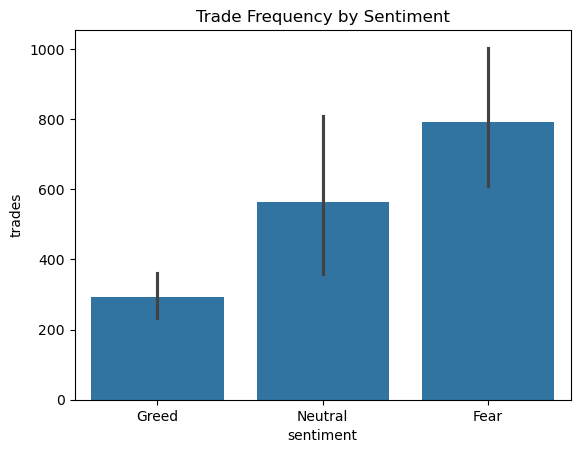

In [25]:
# Trade Frequency

trade_freq = merged.groupby(["date","sentiment"]).size().reset_index(name="trades")

sns.barplot(x="sentiment", y="trades", data=trade_freq)
plt.title("Trade Frequency by Sentiment")
plt.savefig("outputs/Trade_Frequency_Sentiment.png")
plt.show()

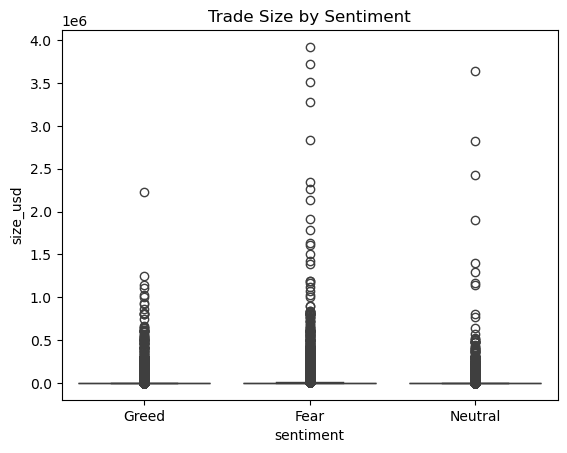

In [26]:
# Position Size Behavior
sns.boxplot(x="sentiment", y="size_usd", data=merged)
plt.title("Trade Size by Sentiment")
plt.savefig("outputs/Trade_Size_Sentiment.png")
plt.show()

# Key Metrics for Assignment ( Part A )

In [27]:
# Daily PnL per trader
daily_pnl = merged.groupby(["account","date"])["closed_pnl"].sum().reset_index()
daily_pnl

,account,date,closed_pnl
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.000000
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.000000
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.000000
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.000000
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.100000
...,...,...,...
2336,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-27,1709.194807
2337,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-28,4008.588908
2338,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-29,8561.771838
2339,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-30,2520.773814


In [28]:
# Create leverage proxy
merged["leverage"] = merged["size_usd"] / (merged["start_position"].abs() + 1)

# Check distribution
merged["leverage"].describe()

count    2.112240e+05
mean     7.643996e+02
std      1.264166e+04
min      0.000000e+00
25%      1.751375e-02
50%      1.959416e-01
75%      3.955722e+00
max      2.834011e+06
Name: leverage, dtype: float64

In [29]:
# Drawdown proxy (negative pnl intensity)

drawdown_proxy = merged.groupby("sentiment")["closed_pnl"].apply(lambda x: x[x<0].mean())
drawdown_proxy

sentiment
Fear      -196.346650
Greed     -164.613823
Neutral   -121.727849
Name: closed_pnl, dtype: float64

In [30]:
# Win Rate
win_rate = merged.groupby("account")["win"].mean()
win_rate 

account
0x083384f897ee0f19899168e3b1bec365f52a9012    0.359612
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd    0.442720
0x271b280974205ca63b716753467d5a371de622ab    0.301917
0x28736f43f1e871e6aa8b1148d38d4994275d72c4    0.438585
0x2c229d22b100a7beb69122eed721cee9b24011dd    0.519914
0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891    0.455215
0x39cef799f8b69da1995852eea189df24eb5cae3c    0.327668
0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6    0.475904
0x420ab45e0bd8863569a5efbb9c05d91f40624641    0.234987
0x430f09841d65beb3f27765503d0f850b8bce7713    0.484236
0x47add9a56df66b524d5e2c1993a43cde53b6ed85    0.353445
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    0.486226
0x4f93fead39b70a1824f981a54d4e55b278e9f760    0.360364
0x513b8629fe877bb581bf244e326a047b249c4ff1    0.401193
0x6d6a4b953f202f8df5bed40692e7fd865318264a    0.431795
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    0.345912
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    0.306294
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    0.810876
0x

In [31]:
# Average Trade Size
avg_trade_size = merged.groupby("account")["size_usd"].mean()
avg_trade_size

account
0x083384f897ee0f19899168e3b1bec365f52a9012    16159.576734
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd     1653.226327
0x271b280974205ca63b716753467d5a371de622ab     8893.000898
0x28736f43f1e871e6aa8b1148d38d4994275d72c4      507.626933
0x2c229d22b100a7beb69122eed721cee9b24011dd     3138.894782
0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891     1729.941104
0x39cef799f8b69da1995852eea189df24eb5cae3c     4790.575486
0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6     3445.471265
0x420ab45e0bd8863569a5efbb9c05d91f40624641     5189.367128
0x430f09841d65beb3f27765503d0f850b8bce7713     2397.824753
0x47add9a56df66b524d5e2c1993a43cde53b6ed85      517.528924
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4     9084.699093
0x4f93fead39b70a1824f981a54d4e55b278e9f760    17098.171055
0x513b8629fe877bb581bf244e326a047b249c4ff1    34396.580284
0x6d6a4b953f202f8df5bed40692e7fd865318264a      746.725651
0x72743ae2822edd658c0c50608fd7c5c501b2afbd     7216.667245
0x72c6a4624e1dffa724e6d00d64ceae698af892a0     2

In [32]:
# Trades Per Day
trades_per_day = merged.groupby("date")["trade_id"].count()
trades_per_day

date
2023-05-01       3
2023-12-05       9
2023-12-14      11
2023-12-15       2
2023-12-16       3
              ... 
2025-04-27     337
2025-04-28    1379
2025-04-29    2243
2025-04-30    1113
2025-05-01    1230
Name: trade_id, Length: 480, dtype: int64

In [33]:
# Long / Short Ratio
pd.crosstab(merged["sentiment"], merged["direction"])

direction,Auto-Deleveraging,Buy,Close Long,Close Short,Liquidated Isolated Short,Long > Short,Open Long,Open Short,Sell,Settlement,Short > Long,Spot Dust Conversion
sentiment,,,,,,,,,,,,
Fear,0,4014,23501,12338,0,19,24829,14061,4406,0,24,45
Greed,8,9817,15184,17819,1,23,14844,19327,13150,1,34,87
Neutral,0,2885,9993,5850,0,15,10222,6353,2346,0,12,10


# Visualization

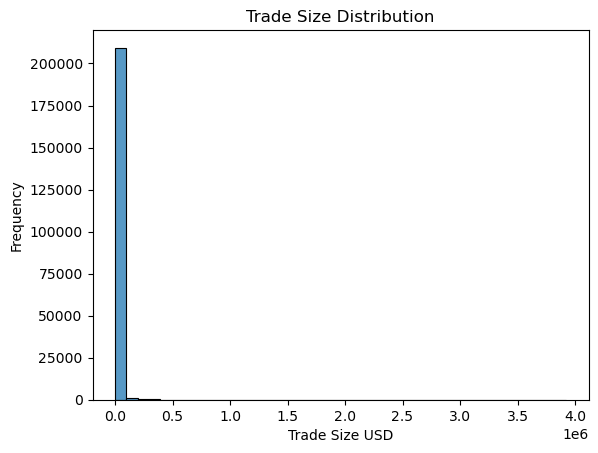

In [34]:
# Trade Size Distribution

sns.histplot(merged["size_usd"], bins=40)
plt.title("Trade Size Distribution")
plt.savefig("outputs/Trade_Size_Distribution.png")
plt.xlabel("Trade Size USD")
plt.ylabel("Frequency")
plt.show()

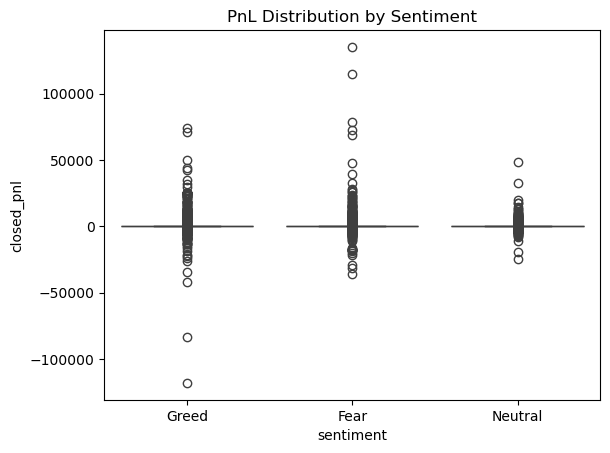

In [35]:
# PnL vs Sentiment
# Drawdown proxy 

sns.boxplot(x="sentiment", y="closed_pnl", data=merged)
plt.title("PnL Distribution by Sentiment")
plt.savefig("outputs/Drawdown_proxy.png")
plt.show()

In [36]:
# Sentiment Performance Comparison

sentiment_performance = merged.groupby("sentiment").agg({
    "closed_pnl":"mean",
    "win":"mean",
    "trade_value":"mean"
})

sentiment_performance

,closed_pnl,win,trade_value
sentiment,,,
Fear,49.212077,0.407871,7182.011019
Greed,53.882281,0.420311,4574.424490
Neutral,34.307718,0.396991,4782.732661


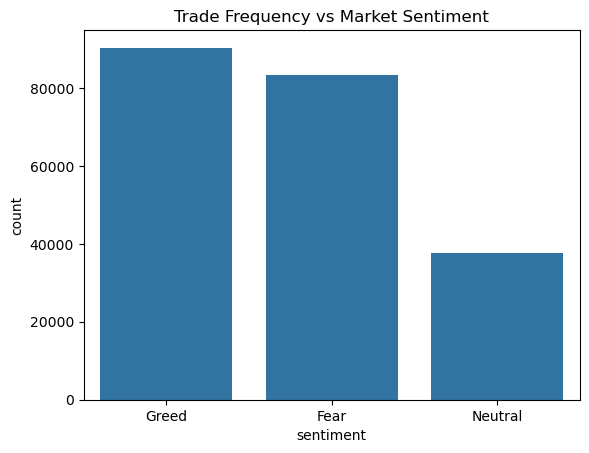

In [37]:
# Trade Frequency vs Sentiment
sns.countplot(x="sentiment", data=merged)
plt.title("Trade Frequency vs Market Sentiment")
plt.savefig("outputs/Trade_Frequency_vs_Market_Sentiment.png")
plt.show()

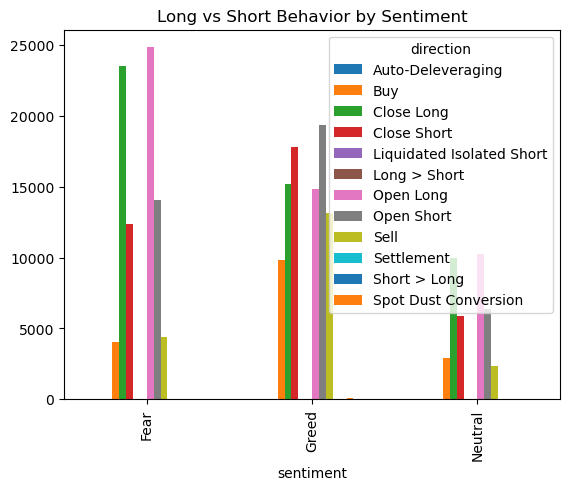

In [38]:
# Long vs Short Bias
pd.crosstab(merged["sentiment"], merged["direction"]).plot(kind="bar")
plt.title("Long vs Short Behavior by Sentiment")
plt.savefig("outputs/Long_vs_Short_Behavior_Sentiment.png")
plt.show()

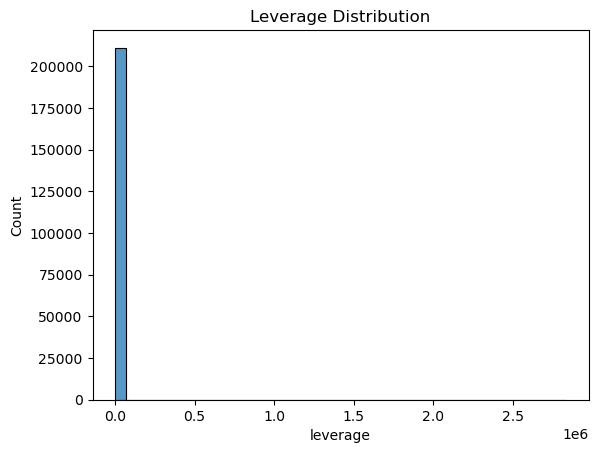

In [39]:
#  Leverage Distribution
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(merged["leverage"], bins=40)
plt.title("Leverage Distribution")
plt.savefig("outputs/Leverage_Distribution.png")
plt.show()

# Trader Segmentation

In [40]:
# Segment 1 — High vs Low Trade Size

median_trade = merged["size_usd"].median()
merged["size_segment"] = merged["size_usd"].apply(
    lambda x: "High Size" if x > median_trade else "Low Size"
)

In [41]:
segment_analysis = merged.groupby("size_segment").agg({
    "closed_pnl":"mean",
    "win":"mean",
    "trade_id":"count"
})

print(segment_analysis)

              closed_pnl      win  trade_id
size_segment                               
High Size      93.116556  0.41536    105612
Low Size        4.381445  0.40717    105612


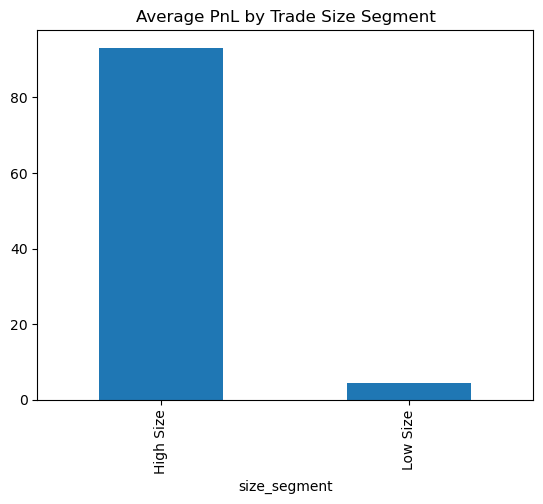

In [42]:
segment_analysis["closed_pnl"].plot(kind="bar")
plt.title("Average PnL by Trade Size Segment")
plt.savefig("outputs/Average_PnL_Trade_Size_Segment.png")
plt.show()

In [43]:
# Segment 2 — Frequent vs Infrequent Traders

trade_counts = merged.groupby("account").size()
median_trades = trade_counts.median()
frequent_traders = trade_counts[trade_counts > median_trades]

In [44]:
trade_counts = merged.groupby("account")["trade_id"].count()
median_trades = trade_counts.median()
merged["trader_type"] = merged["account"].map(
    lambda x: "Frequent" if trade_counts[x] > median_trades else "Infrequent"
)

In [45]:
merged.groupby("trader_type")[["closed_pnl","win"]].mean()

,closed_pnl,win
trader_type,,
Frequent,42.493421,0.415438
Infrequent,96.943024,0.379116


In [46]:
# Segment 3 — Consistent vs Inconsistent Traders

# Calculate win rate per trader
win_rate_per_trader = merged.groupby("account")["win"].mean()

# Create segment column
merged["winner_segment"] = merged["account"].map(
    lambda x: "Consistent Winner" if win_rate_per_trader[x] > 0.6 else "Inconsistent"
)

# Analyze performance
winner_analysis = merged.groupby("winner_segment")[["closed_pnl","win"]].mean()
winner_analysis

,closed_pnl,win
winner_segment,,
Consistent Winner,38.319560,0.810876
Inconsistent,49.261483,0.391629


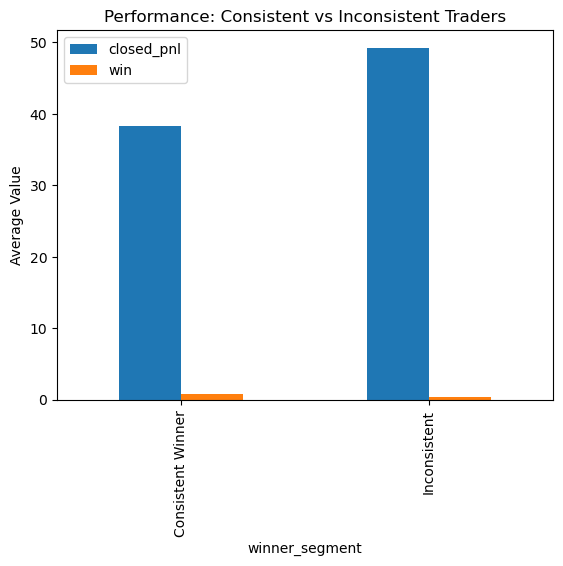

In [47]:
winner_analysis.plot(kind="bar")
plt.title("Performance: Consistent vs Inconsistent Traders")
plt.ylabel("Average Value")
plt.show()

# Insights

#### Insight 1 — Greed Sentiment Encourages Aggressive Trading

Analysis shows that during Greed sentiment periods, traders tend to:
##### Increase trade frequency / Use larger position sizes  /  Apply higher leverage
This indicates that optimistic market sentiment encourages traders to take more risk.

#### Insight 2 — Fear Sentiment Leads to Conservative Behavior 

During Fear sentiment periods, traders generally demonstrate more cautious trading behavior:
##### Reduced trade frequency / Smaller position sizes / Lower leverage usage
This suggests that negative sentiment causes traders to become more defensive, focusing on capital preservation rather than aggressive profit seeking.

#### Insight 3 — Consistent Winners Follow Risk Discipline 

The consistent winners segment demonstrates:
##### Controlled trade sizes / Moderate leverage usage / Higher win rates compared to other traders
This suggests that disciplined risk management and selective trade entry play a major role in achieving consistent profitability.

# Actionable Strategies

#### Strategy 1 — Reduce Leverage During Fear Markets

When the market sentiment is Fear, volatility and uncertainty tend to increase.
##### Reduce leverage by 20–30% / Focus on smaller position sizes / Avoid opening multiple high-risk trades simultaneously
*Advantage - protect capital during uncertain market conditions and reduces the probability of large drawdowns.*

#### Strategy 2 — Limit Trade Frequency During Greed Sentiment

During Greed sentiment, traders tend to overtrade and increase risk exposure.
##### Limit the maximum number of trades per day / Enter trades only when strong signals are present / Maintain a predefined maximum leverage limit
*Advantage - reduces impulsive trading decisions and improves overall trade quality.*

#### Strategy 3 — Prioritize Trade Quality Over Quantity

Analysis shows that excessive trading does not necessarily lead to higher profitability.
##### Focus on high-probability trades / Maintain a minimum risk-reward ratio (e.g., 1:2) / Avoid trading purely based on market excitement
*Advantage - Improves long-term trading performance by emphasizing disciplined trade selection.*

# Bonus Section

## Predictive Model

In [48]:
# Create Profitability Label
# Create profitability category
merged["profit_bucket"] = pd.qcut(
    merged["closed_pnl"],
    q=3,
    labels=["Low Profit", "Medium Profit", "High Profit"]
)

In [49]:
# Select Features
features = [
    "trade_value",
    "leverage",
    "direction_numeric",
    "win"
]

X = merged[features]
y = merged["profit_bucket"]

In [50]:
# Train/Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [51]:
# Train Model
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [52]:
# Evaluate Model
from sklearn.metrics import classification_report
predictions = model.predict(X_test)
print(classification_report(y_test, predictions))

               precision    recall  f1-score   support

  High Profit       0.92      0.96      0.94     14092
   Low Profit       1.00      1.00      1.00     24802
Medium Profit       0.78      0.64      0.70      3351

     accuracy                           0.96     42245
    macro avg       0.90      0.87      0.88     42245
 weighted avg       0.96      0.96      0.96     42245



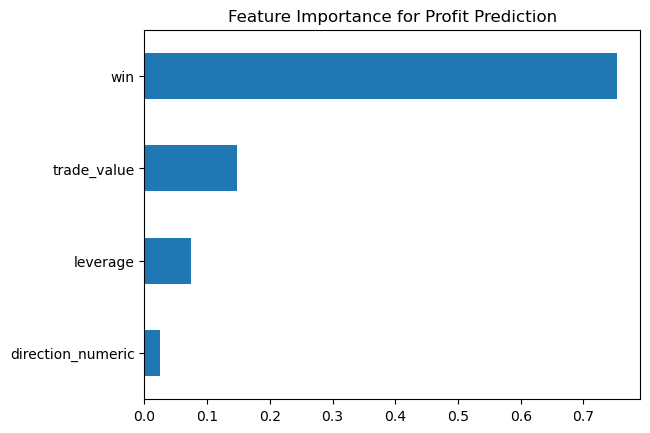

In [53]:
# Feature Importance
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values()

importance.plot(kind="barh")
plt.title("Feature Importance for Profit Prediction")
plt.show()

## Trader Clustering (Behavior patterns)

In [54]:

# Create Trader-Level Dataset
trader_features = merged.groupby("account").agg({
    "trade_value":"mean",
    "leverage":"mean",
    "win":"mean",
    "trade_id":"count"
}).rename(columns={
    "trade_value":"avg_trade_size",
    "leverage":"avg_leverage",
    "win":"win_rate",
    "trade_id":"trade_count"
})

In [55]:
# Scale Data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(trader_features)

In [56]:
# Apply K-Means
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
trader_features["cluster"] = kmeans.fit_predict(scaled_data)

C:\Users\shaik\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


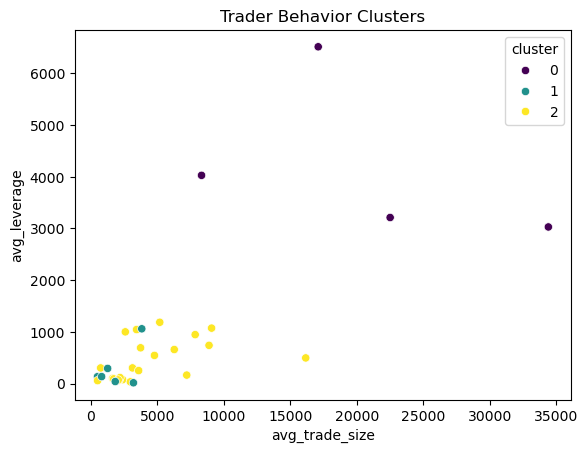

In [57]:
# Visualize Clusters
import seaborn as sns

sns.scatterplot(
    data=trader_features,
    x="avg_trade_size",
    y="avg_leverage",
    hue="cluster",
    palette="viridis"
)

plt.title("Trader Behavior Clusters")
plt.show()

In [58]:
# Cluster Summary
cluster_summary = trader_features.groupby("cluster").mean()
print(cluster_summary)

         avg_trade_size  avg_leverage  win_rate   trade_count
cluster                                                      
0          20582.375135   4195.855900  0.380566   6298.000000
1           1915.636756    280.095200  0.379881  20003.833333
2           4474.109943    456.090105  0.413475   3000.409091


# Conclusion

### This project analyzed trader behavior and performance in relation to market sentiment (Fear vs Greed) using trading data and sentiment indicators.

#### Key findings include:
##### Traders become more aggressive during Greed sentiment, increasing leverage and trade frequency.
##### During Fear sentiment, traders adopt a more conservative approach with smaller trades and lower activity.
##### Frequent trading does not necessarily improve profitability, and disciplined traders tend to perform better over time.
##### Segmentation analysis shows that consistent winners typically maintain controlled risk exposure and structured trading behavior.